# 1.3 Evaluación de calidad

**Actividad 1.3**
- Construye un registro de problemas de calidad: problema, evidencia cuantificada, impacto potencial y tratamiento decidido (corregir, excluir, marcar o aceptar).

**Contenido**: cada sección mide un tipo de problema con una gráfica; 1.3.f los reúne en el registro.

- **1.3.a** Datos Faltantes
- **1.3.b** Datos Duplicados
- **1.3.c** Formato Incorrecto
- **1.3.d** Homologación Catálogo
- **1.3.e** Valores y Fórmulas
- **1.3.f** Registro de calidad completo

</br>

| Artefacto | Ruta |
|---|---|
| Entrada | `0_datos/entrada/KPIS_historico.xlsx` |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pd.set_option("display.max_colwidth", 80)

ARCHIVO = Path("../../0_datos/entrada/KPIS_historico.xlsx")
VERDE, AMARILLO, NARANJA, ROJO, AZUL, MORADO, ROSADO, GRIS, GRIS_CLARO = (
    "#00c389", "#fdda24", "#ff7f41", "#e03c31", "#59cbe8", "#9063cd", "#f5b6cd", "#9e9a99", "#e6e3e2")

CATEGORIAS = {"Faltantes": MORADO, "Duplicados": AZUL, "Formato": AMARILLO, "Catálogo": NARANJA, "Valores": ROSADO}

In [2]:
def simplificar(texto):
    """Minúsculas y sin tildes, para detectar nombres que solo difieren en la escritura."""
    return texto.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")


def limpiar_ejes(ax, lados=("top", "right")):
    ax.spines[list(lados)].set_visible(False)


def barra_apilada(ax, y, valores, colores, texto=lambda grupo, valor: f"{valor:,.0f}", minimo=0):
    """Barra horizontal con un segmento por grupo; los segmentos más angostos que `minimo` llevan el texto afuera."""
    inicio = 0
    for grupo, valor in valores.items():
        if valor == 0:
            continue
        ax.barh(y, valor, left=inicio, color=colores[grupo], edgecolor="white")
        if valor >= minimo:
            ax.text(inicio + valor / 2, y, texto(grupo, valor), ha="center", va="center", fontsize=8)
        else:
            ax.text(inicio + valor, y, " " + texto(grupo, valor), ha="left", va="center", fontsize=8)
        inicio += valor


def leyenda(ax, colores, ncol=5, y=-0.05):
    ax.legend(handles=[Patch(color=c, label=g) for g, c in colores.items()], frameon=False, ncol=ncol,
              loc="upper center", bbox_to_anchor=(0.5, y), fontsize=9)


def pct(n, total):
    return f"{n:,} filas ({n / total:.1%})"

In [3]:
kpis = pd.read_excel(ARCHIVO, sheet_name="query", dtype={"Corte": str, "Codigo_EQU": str, "EQU": str})
cat_indicadores = pd.read_excel(ARCHIVO, sheet_name="catalogo_indicadores", dtype=str)
cat_entornos = pd.read_excel(ARCHIVO, sheet_name="catalogo_entornos", dtype=str)

# Un mismo equipo aparece escrito de varias formas (Equ00074 / EQU00074, EQU0024 / EQU00024): se unifica para contar equipos
kpis["codigo_equipo"] = kpis["Codigo_EQU"].str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)

TOTAL = len(kpis)

## 1.3.a Faltantes

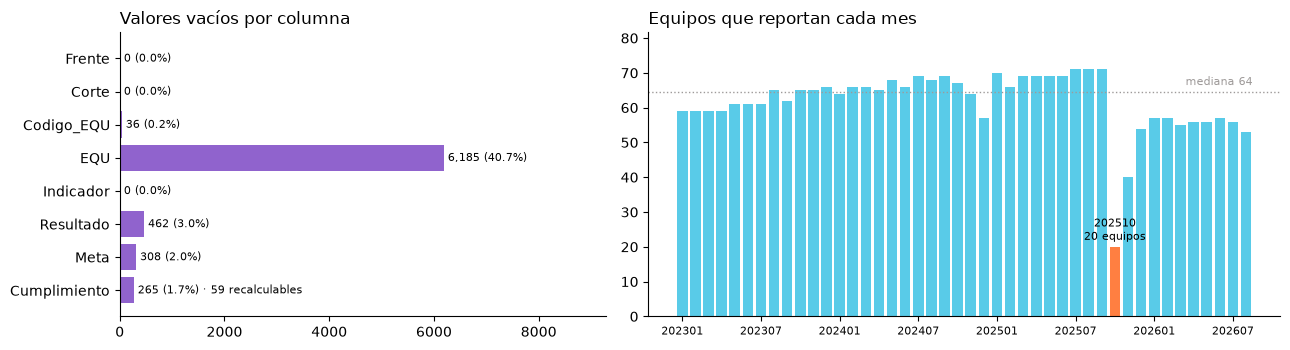

In [4]:
vacios = kpis.drop(columns="codigo_equipo").isna().sum()
sin_cumplimiento = kpis["Cumplimiento"].isna()
recuperable = sin_cumplimiento & kpis["Resultado"].notna() & kpis["Meta"].notna()
equipos_mes = kpis.groupby("Corte")["codigo_equipo"].nunique()
bajos = equipos_mes[equipos_mes < equipos_mes.median() / 2]

fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1, 1.3]})
columnas = vacios.index[::-1]
izq.barh(columnas, vacios[columnas], color=[MORADO if vacios[c] else GRIS for c in columnas])
for i, col in enumerate(columnas):
    detalle = f" · {recuperable.sum()} recalculables" if col == "Cumplimiento" else ""
    izq.text(vacios[col] + 80, i, f"{vacios[col]:,} ({vacios[col] / TOTAL:.1%}){detalle}", va="center", fontsize=8)
izq.set_xlim(0, vacios.max() * 1.5)
izq.set_title("Valores vacíos por columna", loc="left")
limpiar_ejes(izq)

posiciones = range(len(equipos_mes))
der.bar(posiciones, equipos_mes, color=[NARANJA if m in bajos.index else AZUL for m in equipos_mes.index])
der.axhline(equipos_mes.median(), color=GRIS, ls=":", lw=1)
der.text(len(equipos_mes) - 0.5, equipos_mes.median() + 2, f"mediana {equipos_mes.median():.0f}", ha="right", fontsize=8, color=GRIS)
for mes, n in bajos.items():
    der.text(equipos_mes.index.get_loc(mes), n + 2, f"{mes}\n{n} equipos", ha="center", fontsize=8)
der.set_xticks(list(posiciones)[::6], equipos_mes.index[::6], fontsize=8)
der.set_ylim(0, equipos_mes.max() * 1.15)
der.set_title("Equipos que reportan cada mes", loc="left")
limpiar_ejes(der)
plt.tight_layout()
plt.show()

## 1.3.b Duplicados

Cada fila se clasifica una sola vez: copia exacta de otra o con la misma llave (`Frente` + `Corte` + `Codigo_EQU` + `Indicador`) pero otro valor.

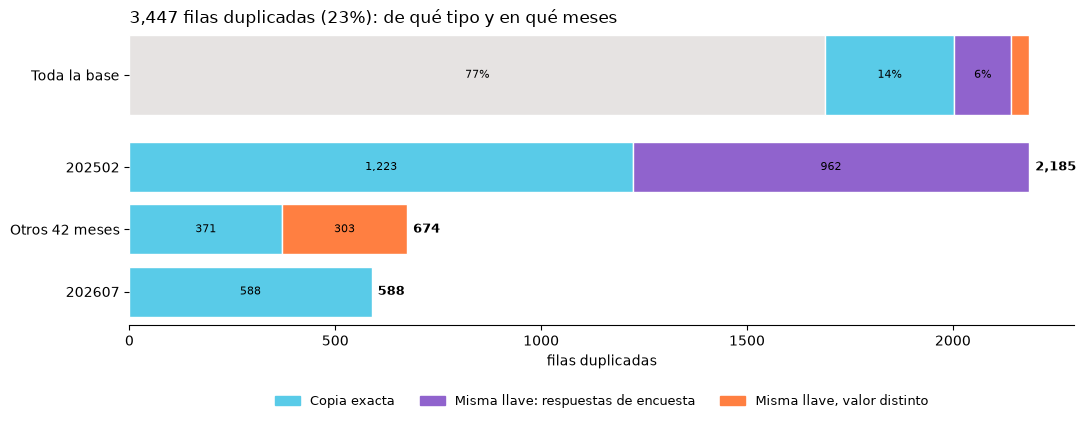

In [5]:
COLUMNAS = ["Frente", "Corte", "Codigo_EQU", "EQU", "Indicador", "Resultado", "Meta", "Cumplimiento"]
LLAVE = ["Frente", "Corte", "codigo_equipo", "Indicador"]
TIPOS = {"Sin duplicado": GRIS_CLARO, "Copia exacta": AZUL,
         "Misma llave: respuestas de encuesta": MORADO, "Misma llave, valor distinto": NARANJA}

tipo_duplicado = pd.Series("Sin duplicado", index=kpis.index)
tipo_duplicado[kpis.duplicated(COLUMNAS)] = "Copia exacta"
pendientes = kpis[(tipo_duplicado == "Sin duplicado") & kpis["codigo_equipo"].notna()]
en_conflicto = pendientes.index[pendientes.duplicated(LLAVE, keep=False)]
es_encuesta = (kpis["Corte"] == "202502") & kpis["Indicador"].isin(["Percepción", "Adopción"])
tipo_duplicado[en_conflicto] = "Misma llave, valor distinto"
tipo_duplicado[en_conflicto[es_encuesta[en_conflicto]]] = "Misma llave: respuestas de encuesta"

conteo = tipo_duplicado.value_counts().reindex(list(TIPOS), fill_value=0)
duplicadas = tipo_duplicado != "Sin duplicado"
meses_top = kpis.loc[duplicadas, "Corte"].value_counts().index[:2]
grupo_mes = kpis["Corte"].where(kpis["Corte"].isin(meses_top), f"Otros {kpis['Corte'].nunique() - 2} meses")
por_mes = pd.crosstab(grupo_mes, tipo_duplicado).reindex(columns=list(TIPOS)[1:], fill_value=0)
por_mes = por_mes.loc[por_mes.sum(axis=1).sort_values().index]

fig, (arriba, abajo) = plt.subplots(2, 1, figsize=(11, 4.4), gridspec_kw={"height_ratios": [1, 2.2]})
barra_apilada(arriba, 0, conteo / TOTAL, TIPOS, texto=lambda g, v: f"{v:.0%}" if v >= 0.04 else "")
arriba.set_yticks([0], ["Toda la base"])
arriba.set_xticks([])
arriba.set_title(f"{duplicadas.sum():,} filas duplicadas ({duplicadas.mean():.0%}): de qué tipo y en qué meses", loc="left")
limpiar_ejes(arriba, ("top", "right", "bottom", "left"))

for j, (mes, fila) in enumerate(por_mes.iterrows()):
    barra_apilada(abajo, j, fila, TIPOS, texto=lambda g, v: f"{v:,}" if v >= 80 else "")
    abajo.text(fila.sum() + 15, j, f"{fila.sum():,}", va="center", fontsize=9, fontweight="bold")
abajo.set_yticks(range(len(por_mes)), por_mes.index)
abajo.set_xlabel("filas duplicadas")
leyenda(abajo, {t: c for t, c in TIPOS.items() if t != "Sin duplicado"}, ncol=4, y=-0.3)
limpiar_ejes(abajo, ("top", "right", "left"))
plt.tight_layout()
plt.show()

## 1.3.c Formato

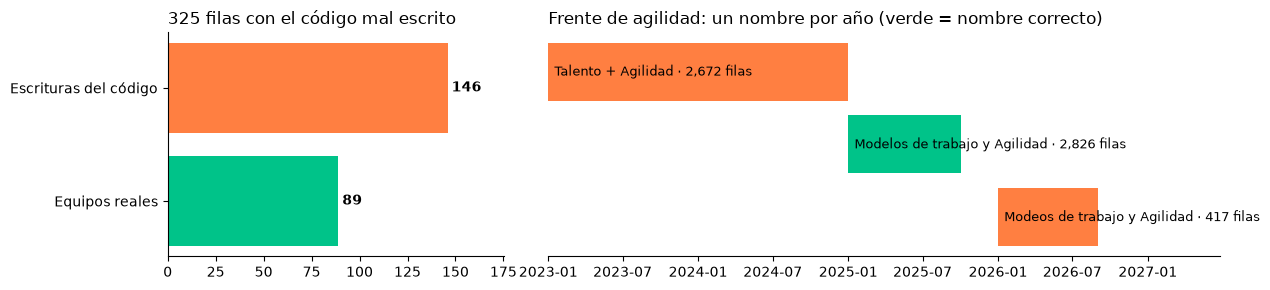

In [6]:
mal_escrito = kpis["Codigo_EQU"].notna() & (kpis["Codigo_EQU"] != kpis["codigo_equipo"])
FRENTES_AGILIDAD = {"Talento + Agilidad": NARANJA, "Modelos de trabajo y Agilidad": VERDE, "Modeos de trabajo y Agilidad": NARANJA}
frente_a_corregir = kpis["Frente"].isin(["Talento + Agilidad", "Modeos de trabajo y Agilidad"])

fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 3), gridspec_kw={"width_ratios": [1, 2]})
escrituras = {"Escrituras del código": kpis["Codigo_EQU"].nunique(), "Equipos reales": kpis["codigo_equipo"].nunique()}
izq.barh(list(escrituras)[::-1], list(escrituras.values())[::-1], color=[VERDE, NARANJA])
for i, n in enumerate(list(escrituras.values())[::-1]):
    izq.text(n + 2, i, str(n), va="center", fontweight="bold")
izq.set_xlim(0, max(escrituras.values()) * 1.2)
izq.set_title(f"{mal_escrito.sum()} filas con el código mal escrito", loc="left")
limpiar_ejes(izq)

fechas = pd.to_datetime(kpis["Corte"], format="%Y%m")
periodos = fechas[kpis["Frente"].isin(FRENTES_AGILIDAD)].groupby(kpis["Frente"]).agg(["min", "max", "size"]).loc[list(FRENTES_AGILIDAD)]
for i, (nombre, p) in enumerate(periodos.iterrows()):
    der.barh(i, p["max"] - p["min"] + pd.Timedelta(days=31), left=p["min"], color=FRENTES_AGILIDAD[nombre])
    der.text(p["min"] + pd.Timedelta(days=15), i, f"{nombre} · {p['size']:,} filas", va="center", fontsize=9)
der.invert_yaxis()
der.set_xlim(right=periodos["max"].max() + pd.Timedelta(days=330))
der.set_yticks([])
der.set_title("Frente de agilidad: un nombre por año (verde = nombre correcto)", loc="left")
limpiar_ejes(der, ("top", "right", "left"))
plt.tight_layout()
plt.show()

## 1.3.d Catálogo

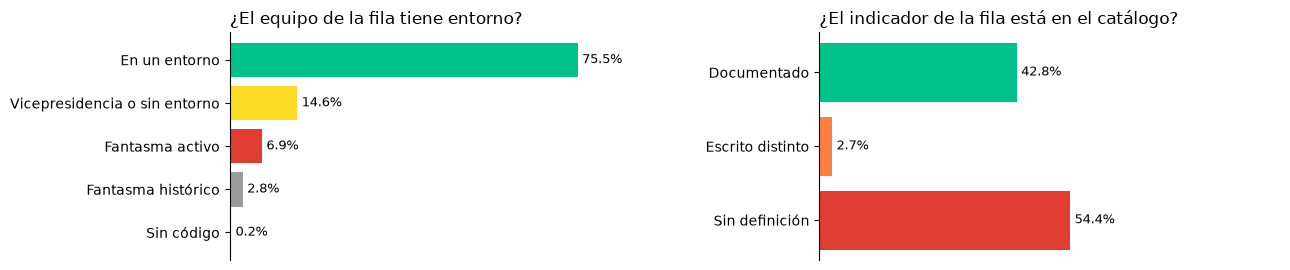

In [7]:
en_catalogo = kpis["codigo_equipo"].isin(cat_entornos["Codigo_EQU"])
padre = kpis["codigo_equipo"].map(cat_entornos.set_index("Codigo_EQU")["Codigo_Padre"])
ultimo_mes = kpis.groupby("codigo_equipo")["Corte"].transform("max")
ubicacion = pd.Series("En un entorno", index=kpis.index)
ubicacion[en_catalogo & ~padre.str.startswith("ENX", na=False)] = "Vicepresidencia o sin entorno"
ubicacion[~en_catalogo & (ultimo_mes >= "202601")] = "Fantasma activo"
ubicacion[~en_catalogo & (ultimo_mes < "202601")] = "Fantasma histórico"
ubicacion[kpis["codigo_equipo"].isna()] = "Sin código"
fantasma = ubicacion.str.startswith("Fantasma")

estado_indicador = pd.Series("Sin definición", index=kpis.index)
estado_indicador[kpis["Indicador"].map(simplificar).isin(cat_indicadores["Indicador"].map(simplificar))] = "Escrito distinto"
estado_indicador[kpis["Indicador"].isin(cat_indicadores["Indicador"])] = "Documentado"
sin_equipos = cat_indicadores[~cat_indicadores["Indicador"].map(simplificar).isin(set(kpis["Indicador"].map(simplificar)))]

GRUPOS = {
    "Equipo": {"En un entorno": VERDE, "Vicepresidencia o sin entorno": AMARILLO, "Fantasma activo": ROJO,
               "Fantasma histórico": GRIS, "Sin código": GRIS_CLARO},
    "Indicador": {"Documentado": VERDE, "Escrito distinto": NARANJA, "Sin definición": ROJO},
}
TITULOS = {"Equipo": "¿El equipo de la fila tiene entorno?", "Indicador": "¿El indicador de la fila está en el catálogo?"}
fig, ejes = plt.subplots(1, 2, figsize=(13, 2.8))
for ax, (nombre, serie) in zip(ejes, [("Equipo", ubicacion), ("Indicador", estado_indicador)]):
    proporcion = serie.value_counts(normalize=True).reindex(list(GRUPOS[nombre]), fill_value=0)[::-1]
    ax.barh(proporcion.index, proporcion, color=[GRUPOS[nombre][g] for g in proporcion.index])
    for i, v in enumerate(proporcion):
        ax.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_title(TITULOS[nombre], loc="left")
    limpiar_ejes(ax, ("top", "right", "bottom"))
plt.tight_layout()
plt.show()

## 1.3.e Valores

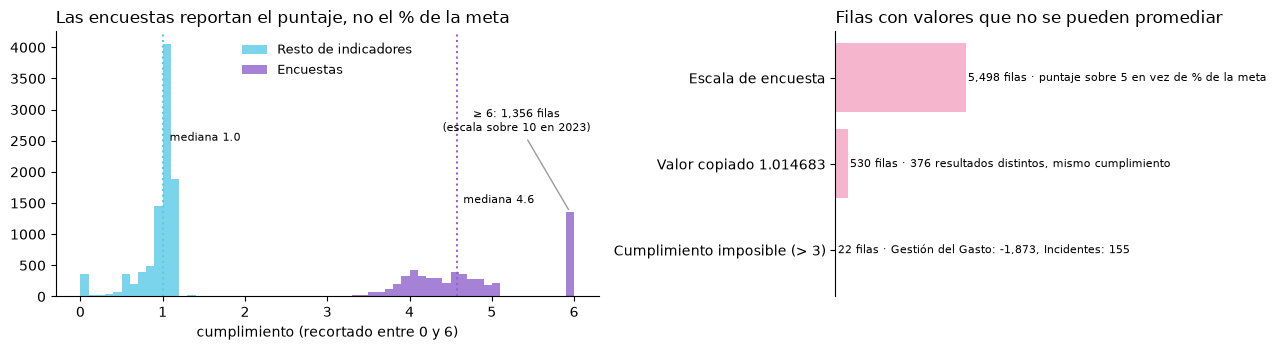

In [8]:
encuestas = kpis["Indicador"].isin(["Percepción", "Adopción", "Talento + Agilidad"])
extremos = (kpis["Cumplimiento"].abs() > 3) & ~encuestas
copiado = (kpis["Cumplimiento"] - 1.014683).abs() < 1e-5
mayor_extremo = kpis[extremos].groupby("Indicador")["Cumplimiento"].agg(lambda s: s.loc[s.abs().idxmax()])

fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1.3, 1]})
for nombre, filas, color, altura in [("Resto de indicadores", ~encuestas, AZUL, 2500), ("Encuestas", encuestas, MORADO, 1500)]:
    valores = kpis.loc[filas, "Cumplimiento"]
    izq.hist(valores.clip(0, 6), bins=60, range=(0, 6), color=color, alpha=0.8, label=nombre)
    izq.axvline(valores.median(), color=color, ls=":", lw=1.5)
    izq.text(valores.median() + 0.08, altura, f"mediana {valores.median():.1f}", fontsize=8)
sobre_6 = (kpis.loc[encuestas, "Cumplimiento"] >= 6).sum()
izq.annotate(f"≥ 6: {sobre_6:,} filas\n(escala sobre 10 en 2023)", xy=(5.95, sobre_6), xytext=(5.3, sobre_6 + 1300),
             fontsize=8, ha="center", arrowprops=dict(arrowstyle="-", color=GRIS, lw=1))
izq.legend(frameon=False, fontsize=9, loc="upper center")
izq.set_xlabel("cumplimiento (recortado entre 0 y 6)")
izq.set_title("Las encuestas reportan el puntaje, no el % de la meta", loc="left")
limpiar_ejes(izq)

problemas = {
    "Escala de encuesta": (encuestas.sum(), "puntaje sobre 5 en vez de % de la meta"),
    "Valor copiado 1.014683": (copiado.sum(), f"{kpis.loc[copiado, 'Resultado'].nunique()} resultados distintos, mismo cumplimiento"),
    "Cumplimiento imposible (> 3)": (extremos.sum(), ", ".join(f"{i}: {v:,.0f}" for i, v in mayor_extremo.items())),
}
for i, (nombre, (n, detalle)) in enumerate(reversed(problemas.items())):
    der.barh(i, n, color=ROSADO)
    der.text(n + 80, i, f"{n:,} filas · {detalle}", va="center", fontsize=8)
der.set_yticks(range(len(problemas)), list(problemas)[::-1])
der.set_xlim(0, encuestas.sum() * 3.2)
der.set_xticks([])
der.set_title("Filas con valores que no se pueden promediar", loc="left")
limpiar_ejes(der, ("top", "right", "bottom"))
plt.tight_layout()
plt.show()

## 1.3.f Registro de calidad

Todos los problemas en una sola vista: cuánto de la base afectan y qué tratamiento se decidió.

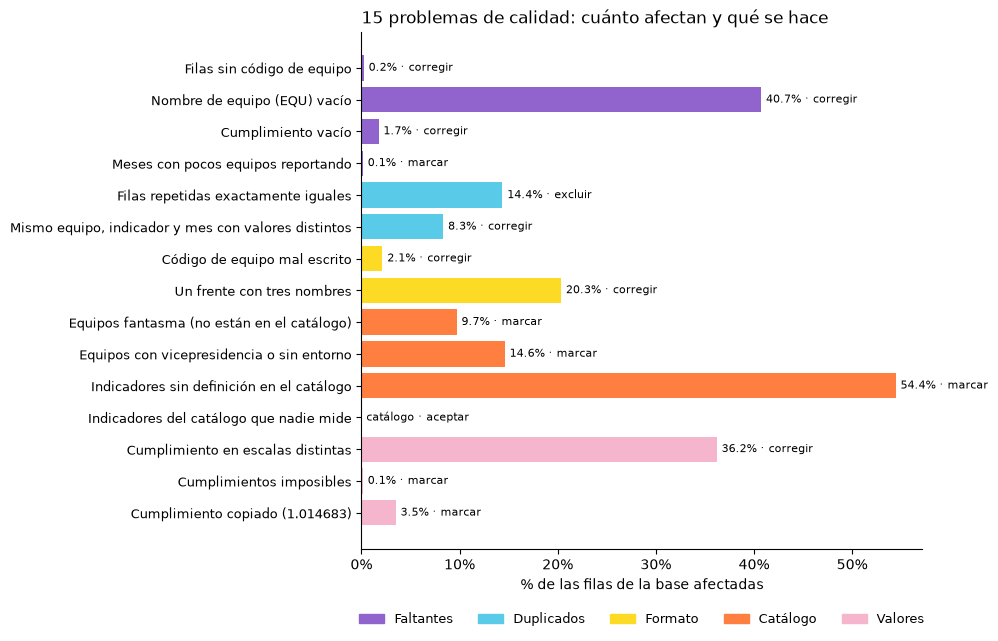

In [9]:
# Las filas sin código sí traen el nombre del equipo, y cada nombre corresponde a un solo código
codigos_por_nombre = kpis.dropna(subset=["codigo_equipo", "EQU"]).groupby("EQU")["codigo_equipo"].nunique()
sin_codigo_recuperable = kpis["codigo_equipo"].isna() & kpis["EQU"].isin(codigos_por_nombre.index[codigos_por_nombre == 1])
copias = tipo_duplicado == "Copia exacta"
mes_copias = kpis.loc[copias, "Corte"].value_counts()
conflicto = tipo_duplicado.str.startswith("Misma llave")
encuesta = tipo_duplicado == "Misma llave: respuestas de encuesta"
activos = kpis.loc[ubicacion == "Fantasma activo", "codigo_equipo"].nunique()

registro = pd.DataFrame([
    ("Faltantes", "Filas sin código de equipo", vacios["Codigo_EQU"],
     f"{pct(vacios['Codigo_EQU'], TOTAL)}; {sin_codigo_recuperable.sum()} tienen un nombre que corresponde a un solo código",
     "Sin código la medición no se asigna a ningún equipo ni entorno.", "corregir (tomar el código del nombre del equipo)"),
    ("Faltantes", "Nombre de equipo (EQU) vacío", vacios["EQU"], pct(vacios["EQU"], TOTAL),
     "Reportes sin nombre legible; el código sí está.", "corregir (tomar el nombre del catálogo o de otras filas del mismo código)"),
    ("Faltantes", "Cumplimiento vacío", sin_cumplimiento.sum(),
     f"{pct(sin_cumplimiento.sum(), TOTAL)}; {recuperable.sum()} se pueden recalcular con Resultado y Meta",
     "Mediciones que no cuentan en el desempeño del equipo.", "corregir las recuperables; excluir el resto"),
    ("Faltantes", "Meses con pocos equipos reportando", kpis["Corte"].isin(bajos.index).sum(),
     ", ".join(f"{m}: {n} equipos" for m, n in bajos.items()) + f" (normal: {equipos_mes.median():.0f})",
     "El promedio del mes representa a pocos equipos.", "marcar (mostrar cuántos equipos hay detrás de cada cifra)"),
    ("Duplicados", "Filas repetidas exactamente iguales", copias.sum(),
     f"{pct(copias.sum(), TOTAL)}; {mes_copias.iloc[0] / copias.sum():.0%} están en {mes_copias.index[0]}",
     "Cuentan doble a algunos equipos y meses e inflan promedios.", "excluir (se deja una)"),
    ("Duplicados", "Mismo equipo, indicador y mes con valores distintos", conflicto.sum(),
     f"{conflicto.sum():,} filas; {encuesta.sum()} son respuestas individuales de encuesta (Percepción/Adopción 202502)",
     "No hay un único valor oficial del mes y los equipos con más respuestas pesan más.",
     "corregir (promedio por equipo, indicador y mes)"),
    ("Formato", "Código de equipo mal escrito", mal_escrito.sum(),
     f"{pct(mal_escrito.sum(), TOTAL)}; {kpis['Codigo_EQU'].nunique()} escrituras para {kpis['codigo_equipo'].nunique()} equipos",
     "Un mismo equipo parece varios equipos distintos.", "corregir (mayúsculas y 5 dígitos)"),
    ("Formato", "Un frente con tres nombres", frente_a_corregir.sum(),
     pct(frente_a_corregir.sum(), TOTAL) + "; Talento + Agilidad (2023-24), Modelos… (2025), Modeos… (2026)",
     "El histórico del frente se ve cortado en tres frentes distintos.",
     "corregir (homologar a 'Modelos de trabajo y Agilidad', también en el catálogo)"),
    ("Catálogo", "Equipos fantasma (no están en el catálogo)", fantasma.sum(),
     f"{pct(fantasma.sum(), TOTAL)} de {kpis.loc[fantasma, 'codigo_equipo'].nunique()} equipos; {activos} siguen activos en 2026",
     "No se pueden agrupar por entorno.", "marcar como 'Sin entorno' y reportar los activos al dueño del catálogo"),
    ("Catálogo", "Equipos con vicepresidencia o sin entorno", (ubicacion == "Vicepresidencia o sin entorno").sum(),
     f"{pct((ubicacion == 'Vicepresidencia o sin entorno').sum(), TOTAL)} de "
     f"{kpis.loc[ubicacion == 'Vicepresidencia o sin entorno', 'codigo_equipo'].nunique()} equipos",
     "Mezclarlos con entornos compara niveles distintos de la organización.",
     "marcar como 'Sin entorno' conservando la vicepresidencia"),
    ("Catálogo", "Indicadores sin definición en el catálogo", (estado_indicador == "Sin definición").sum(),
     f"{kpis.loc[estado_indicador == 'Sin definición', 'Indicador'].nunique()} de {kpis['Indicador'].nunique()} indicadores; "
     f"{pct((estado_indicador == 'Sin definición').sum(), TOTAL)}",
     "No se sabe qué miden, en qué unidad ni si más alto es mejor.", "marcar y documentar con el dueño del indicador"),
    ("Catálogo", "Indicadores del catálogo que nadie mide", 0,
     f"{len(sin_equipos)} de {len(cat_indicadores)}: {', '.join(sin_equipos['Indicador'])} (misma definición)",
     "Catálogo desactualizado o índice consolidado que no llega a la base.", "aceptar y reportar"),
    ("Valores", "Cumplimiento en escalas distintas", encuestas.sum(),
     f"{pct(encuestas.sum(), TOTAL)}; las encuestas reportan el puntaje, no el % de la meta "
     f"(mediana {kpis.loc[encuestas, 'Cumplimiento'].median():.1f} vs {kpis.loc[~encuestas, 'Cumplimiento'].median():.1f})",
     "Promediar cumplimientos favorece 4 veces a los equipos medidos por encuesta.", "corregir (cumplimiento = Resultado / Meta)"),
    ("Valores", "Cumplimientos imposibles", extremos.sum(),
     pct(extremos.sum(), TOTAL) + "; " + ", ".join(f"{i} hasta {v:,.0f}" for i, v in mayor_extremo.items()),
     "Una sola fila extrema domina cualquier promedio.", "marcar y excluir del análisis"),
    ("Valores", "Cumplimiento copiado (1.014683)", copiado.sum(),
     f"{pct(copiado.sum(), TOTAL)} en {', '.join(kpis.loc[copiado, 'Indicador'].unique())}, "
     f"con {kpis.loc[copiado, 'Resultado'].nunique()} resultados distintos",
     "Parece un valor por defecto copiado, no una medición.", "marcar y excluir del análisis"),
], columns=["categoria", "problema", "filas_afectadas", "evidencia", "impacto", "tratamiento"])

orden = registro.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(range(len(orden)), orden["filas_afectadas"] / TOTAL, color=orden["categoria"].map(CATEGORIAS))
for i, fila in enumerate(orden.itertuples()):
    texto = f"{fila.filas_afectadas / TOTAL:.1%}" if fila.filas_afectadas else "catálogo"
    ax.text(fila.filas_afectadas / TOTAL + 0.005, i, f"{texto} · {fila.tratamiento.split(' ')[0]}", va="center", fontsize=8)
ax.set_yticks(range(len(orden)), orden["problema"], fontsize=9)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_xlabel("% de las filas de la base afectadas")
leyenda(ax, CATEGORIAS, y=-0.1)
ax.set_title(f"{len(registro)} problemas de calidad: cuánto afectan y qué se hace", loc="left")
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

In [10]:
# Registro completo con la categoría como etiqueta de color
tabla = registro[["categoria", "problema", "evidencia", "impacto", "tratamiento"]]
display(
    tabla.style.hide(axis="index")
    .map(lambda c: f"background-color: {CATEGORIAS[c]}; color: {'white' if c == 'Faltantes' else '#2a2625'}; font-weight: bold",
         subset=["categoria"])
    .set_properties(**{"text-align": "left", "vertical-align": "top"})
)

categoria,problema,evidencia,impacto,tratamiento
Faltantes,Filas sin código de equipo,36 filas (0.2%); 36 tienen un nombre que corresponde a un solo código,Sin código la medición no se asigna a ningún equipo ni entorno.,corregir (tomar el código del nombre del equipo)
Faltantes,Nombre de equipo (EQU) vacío,"6,185 filas (40.7%)",Reportes sin nombre legible; el código sí está.,corregir (tomar el nombre del catálogo o de otras filas del mismo código)
Faltantes,Cumplimiento vacío,265 filas (1.7%); 59 se pueden recalcular con Resultado y Meta,Mediciones que no cuentan en el desempeño del equipo.,corregir las recuperables; excluir el resto
Faltantes,Meses con pocos equipos reportando,202510: 20 equipos (normal: 64),El promedio del mes representa a pocos equipos.,marcar (mostrar cuántos equipos hay detrás de cada cifra)
Duplicados,Filas repetidas exactamente iguales,"2,182 filas (14.4%); 56% están en 202502",Cuentan doble a algunos equipos y meses e inflan promedios.,excluir (se deja una)
Duplicados,"Mismo equipo, indicador y mes con valores distintos","1,265 filas; 962 son respuestas individuales de encuesta (Percepción/Adopción 202502)",No hay un único valor oficial del mes y los equipos con más respuestas pesan más.,"corregir (promedio por equipo, indicador y mes)"
Formato,Código de equipo mal escrito,325 filas (2.1%); 146 escrituras para 89 equipos,Un mismo equipo parece varios equipos distintos.,corregir (mayúsculas y 5 dígitos)
Formato,Un frente con tres nombres,"3,089 filas (20.3%); Talento + Agilidad (2023-24), Modelos… (2025), Modeos… (2026)",El histórico del frente se ve cortado en tres frentes distintos.,"corregir (homologar a 'Modelos de trabajo y Agilidad', también en el catálogo)"
Catálogo,Equipos fantasma (no están en el catálogo),"1,473 filas (9.7%) de 26 equipos; 8 siguen activos en 2026",No se pueden agrupar por entorno.,marcar como 'Sin entorno' y reportar los activos al dueño del catálogo
Catálogo,Equipos con vicepresidencia o sin entorno,"2,218 filas (14.6%) de 13 equipos",Mezclarlos con entornos compara niveles distintos de la organización.,marcar como 'Sin entorno' conservando la vicepresidencia


**Lectura:** lo que más filas afecta es de **significado**, no de digitación: 54% usa indicadores sin definición y 36% tiene el cumplimiento en otra escala. Resolverlos es requisito para comparar equipos.